In [1]:
import pandas as pd

df = pd.read_csv("bank.csv")

In [2]:
X = df.drop('deposit', axis=1)
y = df['deposit']

In [3]:
for col in X.columns:
    X[col] = X[col].astype('category').cat.codes

In [4]:
y = y.astype('category').cat.codes

In [5]:
print(X.dtypes)

age           int8
job           int8
marital       int8
education     int8
default       int8
balance      int16
housing       int8
loan          int8
contact       int8
day           int8
month         int8
duration     int16
campaign      int8
pdays        int16
previous      int8
poutcome      int8
dtype: object


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

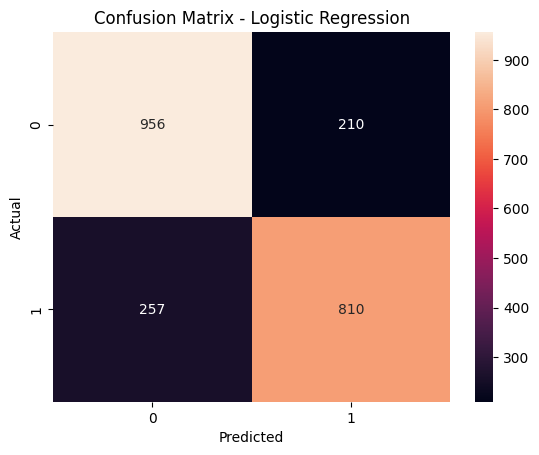

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.79      0.82      0.80      1166
           1       0.79      0.76      0.78      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79      0.79      2233



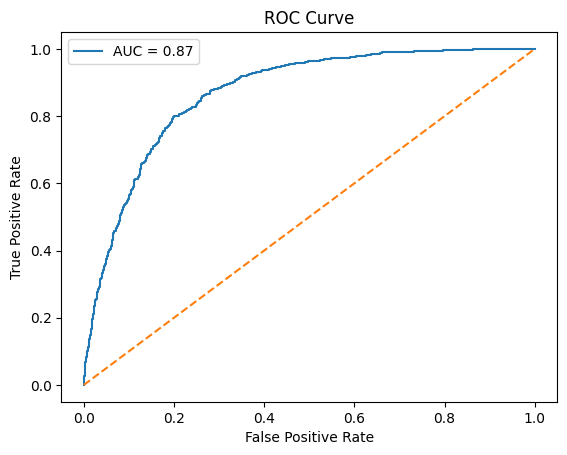

In [13]:
from sklearn.metrics import roc_curve, auc

lr_probs = lr.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, lr_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [14]:
import shap

explainer = shap.Explainer(lr, X_train_scaled)
shap_values = explainer(X_test_scaled)

C:\Users\SL LAPTOP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


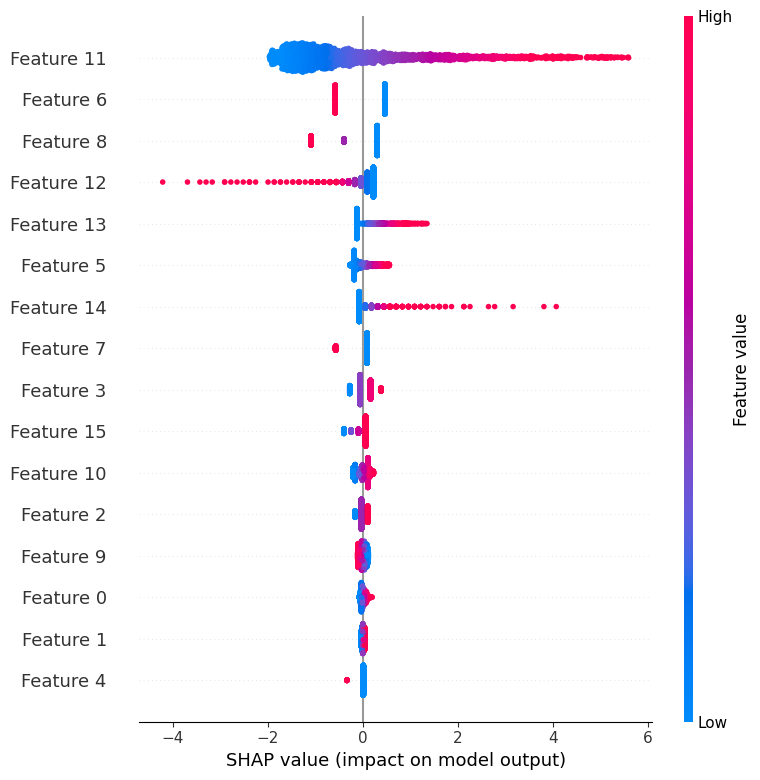

In [15]:
shap.summary_plot(shap_values, X_test)